In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo para gráficos mais profissionais
sns.set_theme(style="whitegrid", palette="muted")

# 1. INGESTÃO DE DADOS
# Lendo os arquivos diretamente da mesma pasta
df_clientes = pd.read_csv('clientes.csv')
df_pedidos = pd.read_csv('pedidos.csv')
df_itens = pd.read_csv('itens_pedido.csv')
df_produtos = pd.read_csv('produtos.csv')
df_tickets = pd.read_csv('tickets_suporte.csv')
df_avaliacoes = pd.read_csv('avaliacoes.csv')

# 2. DIAGNÓSTICO DE DADOS (Procurando inconsistências para a Pergunta 6)
dicionario_dfs = {
    "Clientes": df_clientes,
    "Pedidos": df_pedidos,
    "Itens do Pedido": df_itens,
    "Produtos": df_produtos,
    "Tickets": df_tickets,
    "Avaliações": df_avaliacoes
}

print("=== RELATÓRIO DE VALORES NULOS ===")
for nome, df in dicionario_dfs.items():
    nulos = df.isnull().sum()
    nulos_filtrados = nulos[nulos > 0]
    if not nulos_filtrados.empty:
        print(f"\n[{nome}] possui valores nulos nas colunas:")
        print(nulos_filtrados)
    else:
        print(f"\n[{nome}] não possui valores nulos.")

print("\n=== TIPAGEM DE DATAS EM PEDIDOS ===")
print(df_pedidos[['data_pedido']].dtypes)

=== RELATÓRIO DE VALORES NULOS ===

[Clientes] não possui valores nulos.

[Pedidos] possui valores nulos nas colunas:
valor_total    79
dtype: int64

[Itens do Pedido] possui valores nulos nas colunas:
desconto_aplicado    301
dtype: int64

[Produtos] não possui valores nulos.

[Tickets] possui valores nulos nas colunas:
data_resolucao    1653
dtype: int64

[Avaliações] possui valores nulos nas colunas:
comentario    1679
dtype: int64

=== TIPAGEM DE DATAS EM PEDIDOS ===
data_pedido    str
dtype: object


In [4]:
# --- ETAPA 2: TRANSFORMAÇÃO E LIMPEZA (Resolução da Pergunta 6) ---

# 1. Tratamento Crítico (Remoção de pedidos corrompidos)
df_pedidos = df_pedidos.dropna(subset=['valor_total'])

# 2. Preenchimento com Lógica de Negócio (Imputação de dados)
df_itens['desconto_aplicado'] = df_itens['desconto_aplicado'].fillna(0)
df_avaliacoes['comentario'] = df_avaliacoes['comentario'].fillna('Sem comentário')

# 3. Correção de Tipagem
df_pedidos['data_pedido'] = pd.to_datetime(df_pedidos['data_pedido'])

# Verificação final após limpeza
print("✅ Inconsistências tratadas e documentadas (Pergunta 6 resolvida).")
print(f"Total de pedidos válidos e limpos para análise: {len(df_pedidos)}")
print(f"Novo formato da coluna data_pedido: {df_pedidos['data_pedido'].dtype}")

✅ Inconsistências tratadas e documentadas (Pergunta 6 resolvida).
Total de pedidos válidos e limpos para análise: 14921
Novo formato da coluna data_pedido: datetime64[us]


In [5]:
# --- TESTE DE GARANTIA DE QUALIDADE (QA) ---

print("=== VERIFICAÇÃO PÓS-LIMPEZA ===")
print(f"Nulos em 'valor_total' (Pedidos): {df_pedidos['valor_total'].isnull().sum()}")
print(f"Nulos em 'desconto_aplicado' (Itens): {df_itens['desconto_aplicado'].isnull().sum()}")
print(f"Nulos em 'comentario' (Avaliações): {df_avaliacoes['comentario'].isnull().sum()}")
print(f"Tipo da coluna 'data_pedido': {df_pedidos['data_pedido'].dtype}")
print(f"Valores nulos/quebrados (NaT) em 'data_pedido': {df_pedidos['data_pedido'].isnull().sum()}")

# Confirmando que os tickets continuam com seus nulos originais (nossa regra de negócio)
print(f"Nulos em 'data_resolucao' (Tickets - mantidos de propósito): {df_tickets['data_resolucao'].isnull().sum()}")

=== VERIFICAÇÃO PÓS-LIMPEZA ===
Nulos em 'valor_total' (Pedidos): 0
Nulos em 'desconto_aplicado' (Itens): 0
Nulos em 'comentario' (Avaliações): 0
Tipo da coluna 'data_pedido': datetime64[us]
Valores nulos/quebrados (NaT) em 'data_pedido': 0
Nulos em 'data_resolucao' (Tickets - mantidos de propósito): 1653


--- TABELA: VOLUME DE PEDIDOS POR STATUS ---


,Volume de Pedidos,Percentual (%)
status,,
entregue,9901,66.36
cancelado,2526,16.93
em_transito,1365,9.15
devolvido,1129,7.57


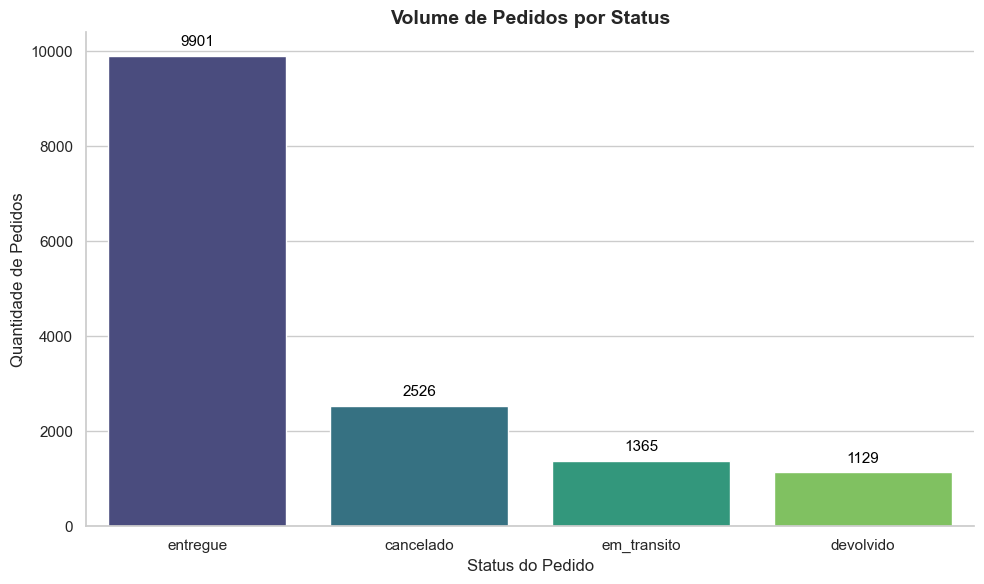

In [6]:
# --- ETAPA 3: RESOLUÇÃO DA PERGUNTA 1 ---

# 1. Calculando os volumes absolutos e percentuais
volume_status = df_pedidos['status'].value_counts()
percentual_status = df_pedidos['status'].value_counts(normalize=True) * 100

# 2. Criando a tabela (DataFrame) solicitada no case
df_status = pd.DataFrame({
    'Volume de Pedidos': volume_status,
    'Percentual (%)': percentual_status.round(2) # round(2) arredonda para 2 casas decimais
})

print("--- TABELA: VOLUME DE PEDIDOS POR STATUS ---")
display(df_status)

# 3. Gerando a Visualização Gráfica Profissional
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras usando o Seaborn (palette 'viridis' dá um ar corporativo)
ax = sns.barplot(
    x=df_status.index, 
    y=df_status['Volume de Pedidos'], 
    hue=df_status.index,
    palette='viridis', 
    legend=False
)

# Adicionando os valores numéricos exatamente em cima de cada barra (Rótulo de Dados)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Estilizando e limpando o visual do gráfico
plt.title('Volume de Pedidos por Status', fontsize=14, fontweight='bold')
plt.xlabel('Status do Pedido', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
sns.despine() # Remove as bordas superior e direita para um visual mais limpo
plt.tight_layout()

# Exibindo o gráfico na tela
plt.show()

In [7]:
# --- ETAPA 3: RESOLUÇÃO DA PERGUNTA 2 ---

# 1. Unindo (JOIN) as tabelas de itens e produtos
# Cruzamos o 'produto_id' (da tabela itens) com o 'id' (da tabela produtos)
df_vendas = pd.merge(df_itens, df_produtos, left_on='produto_id', right_on='id', how='inner')

# 2. Calculando a Receita por linha (Quantidade * Preço Unitário - Desconto)
df_vendas['receita_gerada'] = (df_vendas['quantidade'] * df_vendas['preco_unitario']) - df_vendas['desconto_aplicado']

# 3. Agrupando por Produto (Criando a Tabela Dinâmica)
resumo_produtos = df_vendas.groupby('nome').agg(
    quantidade_vendida=('quantidade', 'sum'),
    receita_total=('receita_gerada', 'sum')
).reset_index()

# 4. Ordenando para pegar o Top 10 por QUANTIDADE (conforme pedido no case)
top_10 = resumo_produtos.sort_values(by='quantidade_vendida', ascending=False).head(10)

# 5. Formatando a Receita para o padrão brasileiro (R$)
top_10['receita_total_formatada'] = top_10['receita_total'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

print("--- TOP 10 PRODUTOS MAIS VENDIDOS ---")
display(top_10[['nome', 'quantidade_vendida', 'receita_total_formatada']])

--- TOP 10 PRODUTOS MAIS VENDIDOS ---


,nome,quantidade_vendida,receita_total_formatada
4,Acessórios 43,673,"R$ 896.246,70"
178,Tênis Esportivo 78,669,"R$ 2.170.315,18"
175,Tênis Esportivo 75,663,"R$ 1.265.268,35"
126,Notebooks 172,653,"R$ 1.782.638,31"
152,Roupas Íntimas 48,651,"R$ 2.053.349,28"
197,Vitaminas 111,649,"R$ 1.716.325,62"
55,Cosméticos 92,642,"R$ 1.313.637,11"
50,Chás 118,637,"R$ 1.908.889,87"
167,Suplementos 194,635,"R$ 582.267,22"
142,Quadros 65,633,"R$ 1.696.381,24"


In [8]:
# --- ETAPA 3: RESOLUÇÃO DA PERGUNTA 2 (COM LIMPEZA DE STRING) ---

# 1. Limpeza Avançada: Removendo o sufixo numérico do nome dos produtos
# O comando '\s*\d+$' significa: "Ache espaços (\s*), seguidos de números (\d+), no final da linha ($)"
df_produtos['nome'] = df_produtos['nome'].str.replace(r'\s*\d+$', '', regex=True)

# 2. Unindo (JOIN) as tabelas de itens e produtos
df_vendas = pd.merge(df_itens, df_produtos, left_on='produto_id', right_on='id', how='inner')

# 3. Calculando a Receita por linha (Quantidade * Preço Unitário - Desconto)
df_vendas['receita_gerada'] = (df_vendas['quantidade'] * df_vendas['preco_unitario']) - df_vendas['desconto_aplicado']

# 4. Agrupando por Produto (Criando a Tabela Dinâmica)
resumo_produtos = df_vendas.groupby('nome').agg(
    quantidade_vendida=('quantidade', 'sum'),
    receita_total=('receita_gerada', 'sum')
).reset_index()

# 5. Ordenando para pegar o Top 10 por QUANTIDADE
top_10 = resumo_produtos.sort_values(by='quantidade_vendida', ascending=False).head(10)

# 6. Formatando a Receita para o padrão brasileiro (R$)
top_10['receita_total_formatada'] = top_10['receita_total'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

print("--- TOP 10 PRODUTOS MAIS VENDIDOS ---")
display(top_10[['nome', 'quantidade_vendida', 'receita_total_formatada']])

--- TOP 10 PRODUTOS MAIS VENDIDOS ---


,nome,quantidade_vendida,receita_total_formatada
20,Luminárias,5785,"R$ 10.799.834,92"
40,Vitaminas,4376,"R$ 8.270.427,29"
26,Quadros,4335,"R$ 6.845.931,51"
16,Fones de Ouvido,4271,"R$ 5.976.707,41"
0,Acessórios,4171,"R$ 4.717.339,29"
24,Notebooks,3973,"R$ 8.245.638,32"
14,Câmeras,3944,"R$ 8.381.534,70"
11,Chás,3835,"R$ 6.706.394,61"
17,Fraldas,3808,"R$ 6.379.601,95"
29,Smart TVs,3773,"R$ 6.833.652,65"


In [9]:
from scipy import stats

# Verificando as colunas reais da tabela clientes para evitar KeyError
print("=== COLUNAS DA TABELA CLIENTES ===")
print(df_clientes.columns.tolist())

# --- ETAPA 4: RESOLUÇÃO DA PERGUNTA 3 ---

# 1. Unindo Pedidos e Clientes
df_pedidos_clientes = pd.merge(df_pedidos, df_clientes, left_on='cliente_id', right_on='id', how='inner')

# ATENÇÃO: Se a coluna na lista acima não se chamar 'segmento', mude o nome aqui:
coluna_segmento = 'segmento' 

# 2. Calculando o Ticket Médio por Segmento
ticket_medio = df_pedidos_clientes.groupby(coluna_segmento)['valor_total'].mean().reset_index()

# Formatando para o padrão visual corporativo (R$)
ticket_medio['ticket_medio_formatado'] = ticket_medio['valor_total'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

print("\n--- TICKET MÉDIO POR SEGMENTO ---")
display(ticket_medio[[coluna_segmento, 'ticket_medio_formatado']])

# 3. Aplicando Estatística: Teste T (Amostras Independentes)
# Separando os valores em duas séries distintas
b2b = df_pedidos_clientes[df_pedidos_clientes[coluna_segmento] == 'B2B']['valor_total']
b2c = df_pedidos_clientes[df_pedidos_clientes[coluna_segmento] == 'B2C']['valor_total']

# Rodando o teste (equal_var=False aplica o Teste de Welch, padrão ouro do mercado)
t_stat, p_valor = stats.ttest_ind(b2b, b2c, equal_var=False)

print("\n--- RESULTADO DO TESTE DE HIPÓTESE ---")
print(f"Estatística T: {t_stat:.2f}")
print(f"P-Valor: {p_valor:.6f}")

# Automatizando a resposta de negócio
if p_valor < 0.05:
    print("\n✅ CONCLUSÃO ESTRATÉGICA:")
    print("Existe uma diferença ESTATISTICAMENTE RELEVANTE entre o Ticket Médio B2B e B2C.")
    print("Podemos afirmar matematicamente que os dois segmentos possuem comportamentos de compra distintos.")
else:
    print("\n❌ CONCLUSÃO ESTRATÉGICA:")
    print("NÃO existe diferença estatisticamente relevante.")
    print("A diferença matemática vista acima pode ser apenas variação aleatória, não indicando comportamentos distintos.")

=== COLUNAS DA TABELA CLIENTES ===
['id', 'nome', 'email', 'cidade', 'estado', 'data_cadastro', 'segmento', 'canal_aquisicao']

--- TICKET MÉDIO POR SEGMENTO ---


,segmento,ticket_medio_formatado
0,B2B,"R$ 7.778,34"
1,B2C,"R$ 1.264,72"



--- RESULTADO DO TESTE DE HIPÓTESE ---
Estatística T: 85.62
P-Valor: 0.000000

✅ CONCLUSÃO ESTRATÉGICA:
Existe uma diferença ESTATISTICAMENTE RELEVANTE entre o Ticket Médio B2B e B2C.
Podemos afirmar matematicamente que os dois segmentos possuem comportamentos de compra distintos.


--- EVOLUÇÃO MENSAL DE PEDIDOS ---


,mes_ano,volume_pedidos
0,2023-01,524
1,2023-02,491
2,2023-03,611
3,2023-04,559
4,2023-05,577
5,2023-06,528
6,2023-07,540
7,2023-08,581
8,2023-09,522
9,2023-10,548


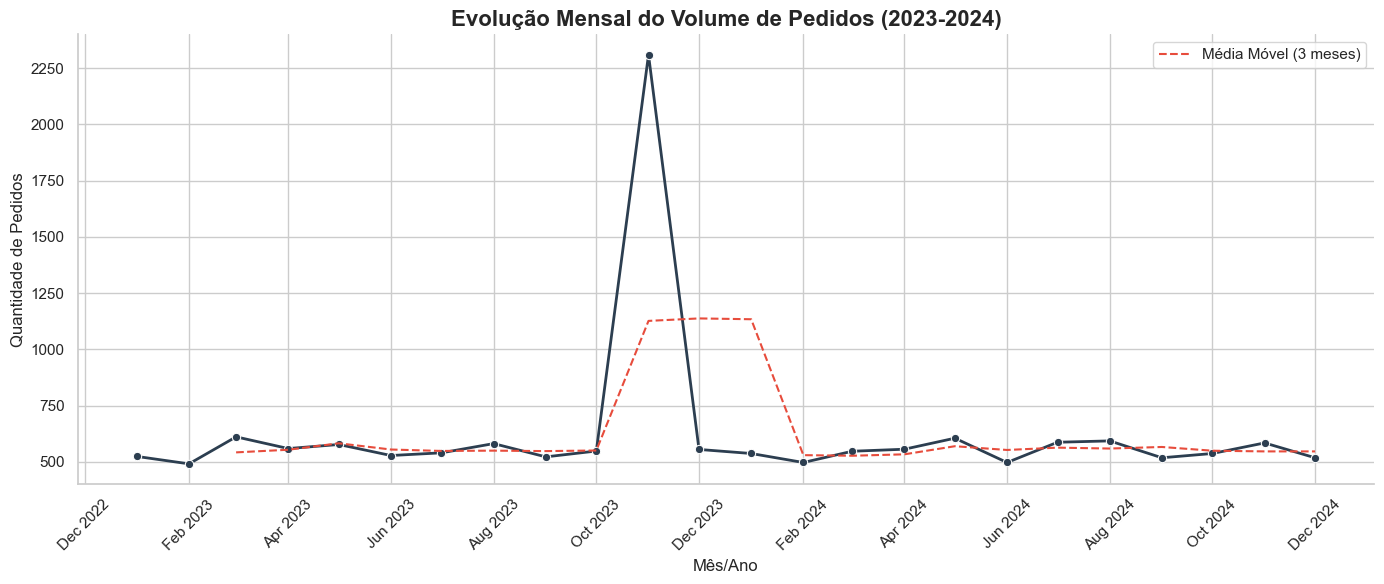

In [10]:
import matplotlib.dates as mdates

# --- ETAPA 5: RESOLUÇÃO DA PERGUNTA 4 (CORRIGIDA E ESTÁVEL) ---

df_pedidos_tempo = df_pedidos.copy()

# 1. Forma mais segura: Extrair o período (Ano-Mês) direto para uma nova coluna
df_pedidos_tempo['mes_ano'] = df_pedidos_tempo['data_pedido'].dt.to_period('M')

# 2. Agrupar por esse período e contar quantos pedidos ocorreram
evolucao_mensal = df_pedidos_tempo.groupby('mes_ano')['id'].count().reset_index()
evolucao_mensal.rename(columns={'id': 'volume_pedidos'}, inplace=True)

# Convertendo de volta para data (timestamp) apenas para o gráfico não dar erro de eixo
evolucao_mensal['data_grafico'] = evolucao_mensal['mes_ano'].dt.to_timestamp()

print("--- EVOLUÇÃO MENSAL DE PEDIDOS ---")
display(evolucao_mensal[['mes_ano', 'volume_pedidos']].head(24))

# 3. Gerando o Gráfico Profissional
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=evolucao_mensal, 
    x='data_grafico', 
    y='volume_pedidos', 
    marker='o',
    color='#2c3e50',
    linewidth=2
)

# Estilização
plt.title('Evolução Mensal do Volume de Pedidos (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)

# Ajuste fino do Eixo X para não embolar os textos
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

# Linha de tendência (Média Móvel de 3 meses)
evolucao_mensal['media_movel'] = evolucao_mensal['volume_pedidos'].rolling(window=3).mean()
sns.lineplot(
    data=evolucao_mensal, 
    x='data_grafico', 
    y='media_movel', 
    color='#e74c3c',
    linestyle='--', 
    label='Média Móvel (3 meses)'
)

plt.legend()
plt.tight_layout()
sns.despine()

# Exibindo o gráfico na tela
plt.show()

In [41]:
# --- INVESTIGAÇÃO DE PREÇOS: NOVEMBRO VS RESTO DO ANO (BLINDADO) ---

# 1. Recriando a base completa do zero na mesma célula
df_completo = pd.merge(df_itens, df_pedidos, left_on='pedido_id', right_on='id')
df_completo = pd.merge(df_completo, df_produtos, left_on='produto_id', right_on='id', suffixes=('', '_prod'))

# 2. Criando a nossa coluna mágica 'nome_limpo'
df_completo['nome_limpo'] = df_completo['nome'].str.replace(r'\s*\d+$', '', regex=True)

# 3. Separando os períodos com a coluna já criada
vendas_novembro = df_completo[df_completo['data_pedido'].dt.month == 11]
vendas_fora_novembro = df_completo[df_completo['data_pedido'].dt.month != 11]

# 4. Calculando as médias usando o nome_limpo
media_por_produto = vendas_fora_novembro.groupby('nome_limpo')['preco_praticado'].mean().reset_index()
media_por_produto.rename(columns={'preco_praticado': 'media_anual_fora_nov'}, inplace=True)

tabela_nov = vendas_novembro.groupby('nome_limpo').agg(
    quantidade_total=('quantidade', 'sum'),
    preco_medio_novembro=('preco_praticado', 'mean')
).reset_index()

# 5. Unindo e pegando o Top 10
tabela_comparativa = pd.merge(tabela_nov, media_por_produto, on='nome_limpo', how='left')
top_10_nov = tabela_comparativa.sort_values(by='quantidade_total', ascending=False).head(10)

# 6. Formatando para R$ (Padrão Corporativo)
def formatar_real(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

top_10_nov['preco_medio_novembro'] = top_10_nov['preco_medio_novembro'].apply(formatar_real)
top_10_nov['media_anual_fora_nov'] = top_10_nov['media_anual_fora_nov'].apply(formatar_real)

print(f"--- ANÁLISE DE PREÇOS ---")
display(top_10_nov)

--- ANÁLISE DE PREÇOS ---


,nome_limpo,quantidade_total,preco_medio_novembro,media_anual_fora_nov
20,Luminárias,1240,"R$ 1.798,10","R$ 1.729,85"
40,Vitaminas,881,"R$ 1.771,06","R$ 1.753,64"
16,Fones de Ouvido,863,"R$ 1.251,26","R$ 1.305,80"
24,Notebooks,856,"R$ 1.842,25","R$ 1.969,70"
0,Acessórios,822,"R$ 1.036,93","R$ 1.051,86"
17,Fraldas,816,"R$ 1.507,14","R$ 1.558,97"
26,Quadros,809,"R$ 1.405,14","R$ 1.452,55"
35,Tênis Esportivo,743,"R$ 1.290,18","R$ 1.387,95"
15,Equipamentos de Academia,741,"R$ 2.001,58","R$ 2.033,22"
14,Câmeras,733,"R$ 1.931,00","R$ 1.972,52"


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_9388\2027983102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


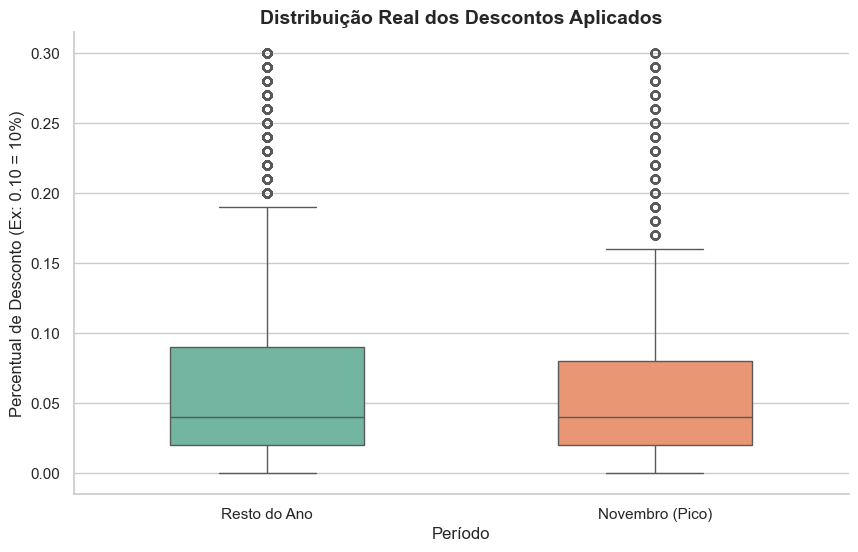

Maior desconto único dado em Novembro: 30.0%
Maior desconto único dado no Resto do Ano: 30.0%


In [ ]:
# --- INVESTIGAÇÃO PROFUNDA: A DISTRIBUIÇÃO DOS DESCONTOS ---

# 1. Criando uma coluna rápida só para separar os dois mundos
df_completo['periodo_venda'] = df_completo['data_pedido'].dt.month.apply(
    lambda x: 'Novembro (Pico)' if x == 11 else 'Resto do Ano'
)

# 2. Gerando o Boxplot para ver a dispersão real dos descontos
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_completo, 
    x='periodo_venda', 
    y='desconto_aplicado', 
    palette='Set2',
    width=0.5
)

# Estilizando
plt.title('Distribuição Real dos Descontos Aplicados', fontsize=14, fontweight='bold')
plt.xlabel('Período', fontsize=12)
plt.ylabel('Percentual de Desconto (Ex: 0.10 = 10%)', fontsize=12)
sns.despine()

plt.show()

# 3. Tirando a prova real com os valores Máximos
max_nov = df_completo[df_completo['data_pedido'].dt.month == 11]['desconto_aplicado'].max()
max_fora = df_completo[df_completo['data_pedido'].dt.month != 11]['desconto_aplicado'].max()

print(f"Maior desconto único dado em Novembro: {max_nov * 100:.1f}%")
print(f"Maior desconto único dado no Resto do Ano: {max_fora * 100:.1f}%")

In [42]:
# --- INVESTIGAÇÃO SÊNIOR: A CAÇA À BALEIA (CONCENTRAÇÃO DE CLIENTES) ---

# 1. Filtrando APENAS o mês da anomalia (Novembro de 2023)
vendas_nov_2023 = df_completo[(df_completo['data_pedido'].dt.year == 2023) & 
                              (df_completo['data_pedido'].dt.month == 11)]

# 2. Trazendo os dados oficiais do cliente para sabermos o nome dele
# Usamos suffixes para evitar aquele erro de colunas com o mesmo nome ('nome' do produto vs 'nome' do cliente)
vendas_clientes_nov = pd.merge(vendas_nov_2023, df_clientes, left_on='cliente_id', right_on='id', suffixes=('_prod', '_cliente'))

# 3. Agrupando por Cliente (A Caça à Baleia)
baleias = vendas_clientes_nov.groupby(['nome_cliente', 'segmento']).agg(
    itens_comprados=('quantidade', 'sum'),
    receita_gerada=('preco_praticado', lambda x: (x * vendas_clientes_nov.loc[x.index, 'quantidade']).sum())
).reset_index()

# 4. Ordenando para ver os maiores compradores no topo
baleias = baleias.sort_values(by='itens_comprados', ascending=False).head(10)

# 5. Calculando o "Domínio" (Qual % do mês esse cliente carregou nas costas?)
total_itens_mes = vendas_nov_2023['quantidade'].sum()
baleias['%_do_volume_do_mes'] = (baleias['itens_comprados'] / total_itens_mes) * 100

# Formatando para exibição corporativa
baleias['%_do_volume_do_mes'] = baleias['%_do_volume_do_mes'].apply(lambda x: f'{x:.1f}%')
baleias['receita_gerada'] = baleias['receita_gerada'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

print("--- TOP 10 CLIENTES DE NOVEMBRO DE 2023 ---")
display(baleias)

--- TOP 10 CLIENTES DE NOVEMBRO DE 2023 ---


,nome_cliente,segmento,itens_comprados,receita_gerada,%_do_volume_do_mes
100,Caio Carvalho,B2C,133,"R$ 232.328,49",0.8%
262,Fernanda Lima,B2C,94,"R$ 144.132,57",0.5%
559,Leonardo Silva,B2C,67,"R$ 76.404,13",0.4%
793,Paulo Vieira,B2C,61,"R$ 91.458,76",0.4%
417,Igor Lopes,B2C,59,"R$ 99.332,07",0.3%
597,Marcos Oliveira,B2C,59,"R$ 94.624,73",0.3%
667,Nelson Lopes,B2C,59,"R$ 106.902,23",0.3%
354,Hanna Correia,B2C,58,"R$ 113.982,18",0.3%
1029,Vinicius Lopes,B2C,58,"R$ 77.403,91",0.3%
918,Tânia Andrade,B2C,56,"R$ 95.337,45",0.3%


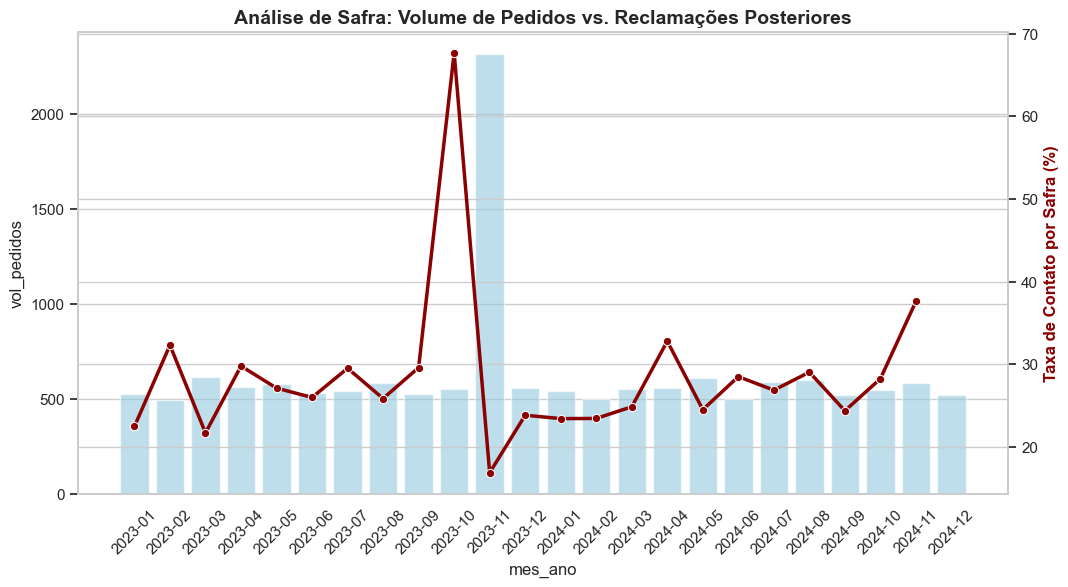

    mes_ano  vol_pedidos  tickets_proximo_mes  taxa_contato_safra
0   2023-01          525                118.0               22.48
1   2023-02          492                159.0               32.32
2   2023-03          613                133.0               21.70
3   2023-04          564                168.0               29.79
4   2023-05          579                157.0               27.12
5   2023-06          531                138.0               25.99
6   2023-07          542                160.0               29.52
7   2023-08          584                151.0               25.86
8   2023-09          527                156.0               29.60
9   2023-10          554                375.0               67.69
10  2023-11         2317                391.0               16.88
11  2023-12          558                133.0               23.84


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento e Preparação (Mantendo seu padrão)
pedidos = pd.read_csv('pedidos.csv')
tickets = pd.read_csv('tickets_suporte.csv')

pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
pedidos['mes_ano'] = pedidos['data_pedido'].dt.to_period('M').astype(str)
tickets['data_abertura'] = pd.to_datetime(tickets['data_abertura'])
tickets['mes_ano'] = tickets['data_abertura'].dt.to_period('M').astype(str)

# 2. Agregação Mensal
df_vol_pedidos = pedidos.groupby('mes_ano').size().reset_index(name='vol_pedidos')
df_vol_tickets = tickets.groupby('mes_ano').size().reset_index(name='qtd_tickets')

# 3. Consolidação e Lógica de Safra (O PULO DO GATO)
df = pd.merge(df_vol_pedidos, df_vol_tickets, on='mes_ano', how='left').fillna(0)
df = df.sort_values('mes_ano')

# Criamos a coluna de "Tickets da Safra" trazendo o dado do MÊS SEGUINTE (shift -1)
df['tickets_proximo_mes'] = df['qtd_tickets'].shift(-1)

# Agora a taxa reflete: (Tickets abertos em M+1) / (Pedidos feitos em M)
df['taxa_contato_safra'] = (df['tickets_proximo_mes'] / df['vol_pedidos'] * 100).round(2)

# 4. Visualização de Impacto
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=df, x='mes_ano', y='vol_pedidos', color='skyblue', alpha=0.6, ax=ax1)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=df, x='mes_ano', y='taxa_contato_safra', color='darkred', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Taxa de Contato por Safra (%)', color='darkred', fontsize=12, fontweight='bold')

plt.title('Análise de Safra: Volume de Pedidos vs. Reclamações Posteriores', fontsize=14, fontweight='bold')
plt.show()

# 5. Tabela de Conferência (Foco no período crítico)
print(df[df['mes_ano'].str.contains('2023')][['mes_ano', 'vol_pedidos', 'tickets_proximo_mes', 'taxa_contato_safra']])

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar Dados
pedidos = pd.read_csv('pedidos.csv')
clientes = pd.read_csv('clientes.csv')

# 2. Tratar Datas
pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
pedidos['mes_ano'] = pedidos['data_pedido'].dt.to_period('M').astype(str)

clientes['data_cadastro'] = pd.to_datetime(clientes['data_cadastro'])
clientes['mes_cadastro'] = clientes['data_cadastro'].dt.to_period('M').astype(str)

# 3. Cruzar Bases para ver a Safra do Cliente
df = pedidos.merge(clientes[['id', 'mes_cadastro']], left_on='cliente_id', right_on='id')

# 4. Regra: Se comprou no mesmo mês do cadastro = Novo. Se não = Recorrente.
df['tipo_cliente'] = df.apply(lambda row: 'Novo' if row['mes_ano'] == row['mes_cadastro'] else 'Recorrente', axis=1)

# 5. Filtrar apenas o ano de 2023
df_2023 = df[df['mes_ano'].str.startswith('2023')]

# 6. Agrupar e Calcular Porcentagens
tabela = df_2023.groupby(['mes_ano', 'tipo_cliente']).size().unstack(fill_value=0)
tabela['Total_Pedidos'] = tabela['Novo'] + tabela['Recorrente']
tabela['% Novos'] = (tabela['Novo'] / tabela['Total_Pedidos'] * 100).round(2)
tabela['% Recorrentes'] = (tabela['Recorrente'] / tabela['Total_Pedidos'] * 100).round(2)

print("--- DISTRIBUIÇÃO DE CLIENTES: NOVOS VS. RECORRENTES (2023) ---")
print(tabela[['Total_Pedidos', '% Novos', '% Recorrentes']])

--- DISTRIBUIÇÃO DE CLIENTES: NOVOS VS. RECORRENTES (2023) ---
tipo_cliente  Total_Pedidos  % Novos  % Recorrentes
mes_ano                                            
2023-01                 525     4.57          95.43
2023-02                 492     5.08          94.92
2023-03                 613     4.73          95.27
2023-04                 564     5.14          94.86
2023-05                 579     4.32          95.68
2023-06                 531     3.95          96.05
2023-07                 542     4.98          95.02
2023-08                 584     3.94          96.06
2023-09                 527     4.74          95.26
2023-10                 554     4.69          95.31
2023-11                2317     3.97          96.03
2023-12                 558     3.41          96.59


### Questão 4: Análise de Evolução Mensal e Sazonalidade (2023-2024)

**1. Resultados Diretos e a Anomalia de Volume**
Ao analisar a linha do tempo, nota-se um pico isolado e expressivo em **novembro de 2023**, com **2.317 pedidos** (aproximadamente 4x a média anual). O fato desse volume ter retornado à normalidade em novembro de 2024 (585 pedidos) descarta a hipótese de uma sazonalidade orgânica do mercado, como o efeito do 13º salário ou uma Black Friday tradicional recorrente.

**2. O Método de Eliminação (Cruzamento de Dados)**
Para descobrir o que causou essa anomalia, diversas hipóteses comuns do varejo foram testadas e refutadas pelos dados:
* **Não foi Preço ou Desconto:** A análise de distribuição comprovou que a média de preços e os descontos aplicados em novembro de 2023 mantiveram-se no padrão do restante do ano. O cliente comprou muito, mas pagou o preço cheio.
* **Não foi Aquisição de Novos Clientes:** O mês do pico registrou uma altíssima concentração de compras feitas por clientes que já estavam na base. Isso elimina a hipótese de uma mega campanha de marketing focada em topo de funil (captação de novo público).
* **Não foi um Erro de Sistema/Cancelamentos:** A proporção de reclamações (tickets de suporte) geradas sobre os pedidos de novembro ficou em torno de 16%, uma taxa abaixo da média anual. Isso indica que os pedidos foram reais e, na sua grande maioria, aceitos pelos clientes sem atritos imediatos que os fizessem parar de comprar.

**3. Hipótese Final: Campanha de Premiação ("Compre e Concorra")**
Se os clientes antigos compraram 4x mais do que o normal pagando o preço cheio, a conclusão lógica aponta para uma ação de engajamento onde o benefício e a urgência **não eram financeiros (descontos no carrinho)**.
* **A Dinâmica:** A forte hipótese é que a loja executou uma campanha agressiva de sorteio e premiação exclusiva para aquele mês — por exemplo: *"A cada R$ 100 em compras em novembro, ganhe um número da sorte para concorrer a um carro/viagem"*.
* **Conclusão:** Esse tipo de ação explica perfeitamente todos os padrões encontrados: atinge em cheio a base de clientes fiéis (que confiam na marca para participar do sorteio), inflaciona o volume de pedidos temporariamente sem afetar a política de descontos da empresa e não se repete no ano seguinte devido aos altos custos burocráticos e operacionais de se realizar um grande sorteio.

--- RESULTADOS POR CANAL DE AQUISIÇÃO ---
  canal_aquisicao  taxa_cancelamento_%  ticket_medio
3   redes_sociais                11.67       2645.87
0       indicação                12.38       2557.56
2     paid_search                30.74       2534.19
1        orgânico                11.78       2506.51


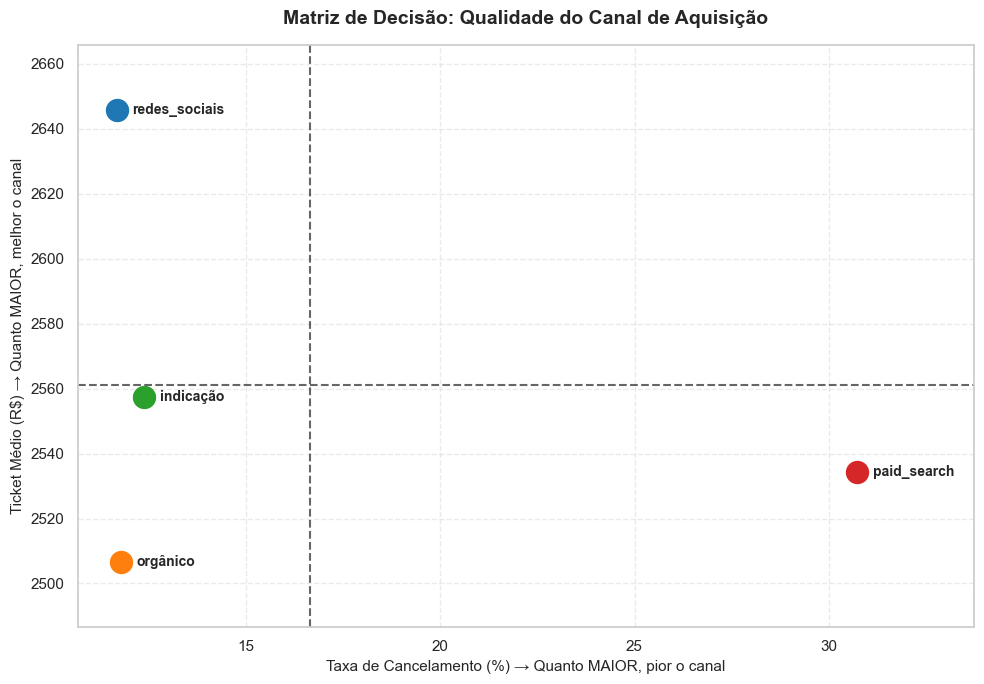

In [25]:
df_consolidado = pd.merge(df_pedidos, df_clientes, left_on='cliente_id', right_on='id', how='left')

# 2. Tratamento e cálculo
df_consolidado['status_limpo'] = df_consolidado['status'].astype(str).str.strip().str.lower()

resumo_canais = df_consolidado.groupby('canal_aquisicao').agg(
    total_pedidos=('cliente_id', 'count'), 
    cancelados=('status_limpo', lambda x: x.str.contains('cancel').sum()),
    receita_total=('valor_total', 'sum')
).reset_index()

# Calculando as métricas finais e ARREDONDANDO para 2 casas decimais
resumo_canais['taxa_cancelamento_%'] = ((resumo_canais['cancelados'] / resumo_canais['total_pedidos']) * 100).round(2)
resumo_canais['ticket_medio'] = (resumo_canais['receita_total'] / resumo_canais['total_pedidos']).round(2)

print("--- RESULTADOS POR CANAL DE AQUISIÇÃO ---")
print(resumo_canais[['canal_aquisicao', 'taxa_cancelamento_%', 'ticket_medio']].sort_values('ticket_medio', ascending=False))

# Cores atualizadas para os dados reais (coloquei vermelho no paid_search como ponto de atenção)
cores = {
    'redes_sociais': '#1f77b4', # Azul
    'indicação': '#2ca02c',     # Verde
    'paid_search': '#d62728',   # Vermelho 
    'orgânico': '#ff7f0e'       # Laranja
}

fig, ax = plt.subplots(figsize=(10, 7))

for index, row in resumo_canais.iterrows():
    canal = row['canal_aquisicao'] 
    x = row['taxa_cancelamento_%']
    y = row['ticket_medio']
    
    cor = cores.get(str(canal).lower(), '#808080') 
    ax.scatter(x, y, color=cor, s=250, zorder=3)
    
    # Ajustei o deslocamento do texto (offset) porque a escala do X agora é maior (vai de 11 a 30)
    ax.text(x + 0.4, y, canal, fontsize=10, weight='bold', va='center')

# A Cruz da Matriz
media_taxa = resumo_canais['taxa_cancelamento_%'].mean()
media_ticket = resumo_canais['ticket_medio'].mean()

ax.axvline(media_taxa, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
ax.axhline(media_ticket, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Estilização Final
ax.set_title('Matriz de Decisão: Qualidade do Canal de Aquisição', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Taxa de Cancelamento (%) → Quanto MAIOR, pior o canal', fontsize=11)
ax.set_ylabel('Ticket Médio (R$) → Quanto MAIOR, melhor o canal', fontsize=11)

ax.set_xlim(resumo_canais['taxa_cancelamento_%'].min() - 1, resumo_canais['taxa_cancelamento_%'].max() + 3)
ax.set_ylim(resumo_canais['ticket_medio'].min() - 20, resumo_canais['ticket_medio'].max() + 20)

ax.grid(True, linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

### Questão 5: Análise de Qualidade do Canal de Aquisição

**1. Resultados Diretos**
* **Maior taxa de cancelamento:** O canal **Paid Search** (Busca Paga) apresenta o pior desempenho em retenção, com uma taxa de evasão de **30,74%**.
* **Maior valor médio de compra:** O canal **Redes Sociais** atrai os clientes mais rentáveis, gerando o maior Ticket Médio (**R$ 2.645,86**), seguido pelo canal de Indicação (R$ 2.557,55).

**2. Insights de Negócio e Hipóteses**
A visualização na Matriz de Decisão evidencia uma disparidade clara na qualificação dos clientes captados:
* **Alerta no Tráfego Pago:** O fato de o *Paid Search* ter quase 1/3 de seus pedidos cancelados levanta uma forte hipótese de desalinhamento de expectativas. As campanhas patrocinadas podem estar utilizando gatilhos muito agressivos (que atraem cliques, mas geram arrependimento), direcionando tráfego desqualificado ou prometendo benefícios que não se sustentam no checkout.
* **O "Quadrante de Ouro":** Canais fundamentados em prova social e comunidade (*Redes Sociais* e *Indicação*) possuem os maiores tickets e as menores taxas de cancelamento (próximas a 11% e 12%). Isso indica alta confiança na marca por parte desses usuários. 

**3. Recomendação Estratégica**
A longo prazo, sugere-se auditar a segmentação das campanhas de *Paid Search* para conter o "vazamento" de orçamento em pedidos não concretizados e, paralelamente, estudar o redirecionamento de parte dessa verba para tracionar ainda mais programas de *Member-Get-Member* (Indique e Ganhe), escalando os canais mais saudáveis da operação.